# Tarea 2: Secuenciación de Tareas
## MA2015 - Diseño de Algoritmos Bioinspirados

**Autoras:** Viviana Carrizales Luna (A01286191) & Steffany Mishell Lara Muy (A00838589)

*Instituto Tecnológico y de Estudios Superiores de Monterrey (ITESM)*


## Descripción del Problema

Dado un conjunto $M = \{1, 2, \dots, m\}$ de tareas que se van a secuenciar en una sola máquina, cada tarea $i \in M$ tiene:

- $t_i$: tiempo de procesamiento
- $d_i$: fecha límite
- $h_i$: costo de retención por unidad de tiempo
- $c_i$: costo de penalización por unidad de tiempo (si se retrasa)

**Objetivo:** Minimizar los costos totales por retención y penalización.

### Datos del Problema

| Tarea $i$ | $t_i$ | $d_i$ | $h_i$ | $c_i$ |
|-----------|-------|-------|-------|-------|
| 1         | 10    | 15    | 3     | 10    |
| 2         | 8     | 20    | 2     | 22    |
| 3         | 6     | 10    | 5     | 10    |
| 4         | 7     | 30    | 4     | 8     |
| 5         | 4     | 12    | 6     | 15    |

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from itertools import permutations
import pandas as pd
from typing import List, Tuple

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
random.seed(42)

## 1. Modelo Matemático

### Variables de Decisión

Sea $\pi = (\pi_1, \pi_2, \dots, \pi_m)$ una permutación de las tareas.

Para cada tarea $i$ en la posición $j$ de la secuencia:
- $C_i$: tiempo de completación de la tarea $i$
- $E_i = \max(0, d_i - C_i)$: tiempo de anticipación (early)
- $T_i = \max(0, C_i - d_i)$: tiempo de tardanza (tardy)

### Función Objetivo

$$\min Z = \sum_{i=1}^{m} (h_i \cdot E_i + c_i \cdot T_i)$$

Donde:
- $h_i \cdot E_i$: costo de retención (si la tarea termina antes de $d_i$)
- $c_i \cdot T_i$: costo de penalización (si la tarea termina después de $d_i$)

### Cálculo de Tiempos de Completación

Para una secuencia $\pi$:
$$C_{\pi_1} = t_{\pi_1}$$
$$C_{\pi_j} = C_{\pi_{j-1}} + t_{\pi_j} \quad \forall j = 2, \dots, m$$

In [11]:
# Datos del problema
tareas = {
    1: {'t': 10, 'd': 15, 'h': 3, 'c': 10},
    2: {'t': 8,  'd': 20, 'h': 2, 'c': 22},
    3: {'t': 6,  'd': 10, 'h': 5, 'c': 10},
    4: {'t': 7,  'd': 30, 'h': 4, 'c': 8},
    5: {'t': 4,  'd': 12, 'h': 6, 'c': 15}
}

n_tareas = len(tareas)

# Mostrar datos
df_tareas = pd.DataFrame(tareas).T
print("Datos de las tareas:")
print(df_tareas)

Datos de las tareas:
    t   d  h   c
1  10  15  3  10
2   8  20  2  22
3   6  10  5  10
4   7  30  4   8
5   4  12  6  15


### Función de Evaluación

In [12]:
def calcular_costo(secuencia: List[int], tareas: dict, verbose: bool = False) -> Tuple[float, dict]:
    """
    Calcula el costo total de una secuencia de tareas.
    
    Parámetros:
    -----------
    secuencia : List[int]
        Lista con el orden de las tareas (1-indexed)
    tareas : dict
        Diccionario con los datos de cada tarea
    verbose : bool
        Si es True, muestra detalles del cálculo
    
    Retorna:
    --------
    costo_total : float
        Costo total de la secuencia
    detalles : dict
        Diccionario con detalles de cada tarea
    """
    tiempo_actual = 0
    costo_total = 0
    detalles = {}
    
    for tarea_id in secuencia:
        # Obtener datos de la tarea
        t_i = tareas[tarea_id]['t']  # tiempo de procesamiento
        d_i = tareas[tarea_id]['d']  # fecha límite
        h_i = tareas[tarea_id]['h']  # costo de retención
        c_i = tareas[tarea_id]['c']  # costo de penalización
        
        # Calcular tiempo de completación
        tiempo_actual += t_i
        C_i = tiempo_actual
        
        # Calcular anticipación y tardanza
        E_i = max(0, d_i - C_i)  # early (anticipación)
        T_i = max(0, C_i - d_i)  # tardy (tardanza)
        
        # Calcular costos
        costo_retencion = h_i * E_i
        costo_penalizacion = c_i * T_i
        costo_tarea = costo_retencion + costo_penalizacion
        
        costo_total += costo_tarea
        
        # Guardar detalles
        detalles[tarea_id] = {
            'C': C_i,
            'E': E_i,
            'T': T_i,
            'costo_retencion': costo_retencion,
            'costo_penalizacion': costo_penalizacion,
            'costo_total': costo_tarea
        }
        
        if verbose:
            print(f"Tarea {tarea_id}: C={C_i}, d={d_i}, E={E_i}, T={T_i}, "
                  f"Costo={costo_tarea:.2f} (ret={costo_retencion:.2f}, pen={costo_penalizacion:.2f})")
    
    return costo_total, detalles

### Solución Óptima por Fuerza Bruta

Para validar el algoritmo genético, resolveremos el problema evaluando todas las permutaciones posibles.

In [13]:
def resolver_fuerza_bruta(tareas: dict) -> Tuple[List[int], float]:
    """
    Resuelve el problema por fuerza bruta evaluando todas las permutaciones.
    
    Retorna:
    --------
    mejor_secuencia : List[int]
        Secuencia óptima
    mejor_costo : float
        Costo de la secuencia óptima
    """
    mejor_costo = float('inf')
    mejor_secuencia = None
    n = len(tareas)
    
    # Evaluar todas las permutaciones
    for perm in permutations(range(1, n + 1)):
        costo, _ = calcular_costo(list(perm), tareas)
        if costo < mejor_costo:
            mejor_costo = costo
            mejor_secuencia = list(perm)
    
    return mejor_secuencia, mejor_costo

# Resolver por fuerza bruta
print("Resolviendo por fuerza bruta...")
print(f"Total de permutaciones a evaluar: {math.factorial(n_tareas)}\n")

secuencia_optima, costo_optimo = resolver_fuerza_bruta(tareas)


print("SOLUCIÓN ÓPTIMA (Fuerza Bruta)")

print(f"Secuencia óptima: {secuencia_optima}")
print(f"Costo óptimo: {costo_optimo:.2f}")
print("\nDetalles de la secuencia óptima:")
print("-"*60)
_, detalles_optimo = calcular_costo(secuencia_optima, tareas, verbose=True)

Resolviendo por fuerza bruta...
Total de permutaciones a evaluar: 120

SOLUCIÓN ÓPTIMA (Fuerza Bruta)
Secuencia óptima: [3, 5, 2, 1, 4]
Costo óptimo: 206.00

Detalles de la secuencia óptima:
------------------------------------------------------------
Tarea 3: C=6, d=10, E=4, T=0, Costo=20.00 (ret=20.00, pen=0.00)
Tarea 5: C=10, d=12, E=2, T=0, Costo=12.00 (ret=12.00, pen=0.00)
Tarea 2: C=18, d=20, E=2, T=0, Costo=4.00 (ret=4.00, pen=0.00)
Tarea 1: C=28, d=15, E=0, T=13, Costo=130.00 (ret=0.00, pen=130.00)
Tarea 4: C=35, d=30, E=0, T=5, Costo=40.00 (ret=0.00, pen=40.00)


## 2. Algoritmo Genético

### Pseudocódigo

```
ALGORITMO Genético_Secuenciación_Tareas

ENTRADA:
    - tareas: información de las tareas (t_i, d_i, h_i, c_i)
    - tam_poblacion: tamaño de la población
    - generaciones: número máximo de generaciones
    - prob_cruce: probabilidad de cruce
    - prob_mutacion: probabilidad de mutación

INICIO
    // Inicialización
    poblacion ← generar_poblacion_inicial(tam_poblacion)
    evaluar_poblacion(poblacion)
    mejor_individuo ← obtener_mejor(poblacion)
    
    PARA generacion = 1 HASTA generaciones HACER
        nueva_poblacion ← LISTA_VACIA
        
        // Elitismo: preservar el mejor individuo
        nueva_poblacion.agregar(mejor_individuo)
        
        MIENTRAS tamaño(nueva_poblacion) < tam_poblacion HACER
            // Selección
            padre1 ← seleccion_torneo(poblacion)
            padre2 ← seleccion_torneo(poblacion)
            
            // Cruce
            SI random() < prob_cruce ENTONCES
                hijo1, hijo2 ← cruce_OX(padre1, padre2)
            SINO
                hijo1, hijo2 ← padre1, padre2
            FIN SI
            
            // Mutación
            SI random() < prob_mutacion ENTONCES
                hijo1 ← mutacion_swap(hijo1)
            FIN SI
            SI random() < prob_mutacion ENTONCES
                hijo2 ← mutacion_swap(hijo2)
            FIN SI
            
            nueva_poblacion.agregar(hijo1)
            SI tamaño(nueva_poblacion) < tam_poblacion ENTONCES
                nueva_poblacion.agregar(hijo2)
            FIN SI
        FIN MIENTRAS
        
        poblacion ← nueva_poblacion
        evaluar_poblacion(poblacion)
        
        // Actualizar mejor individuo
        mejor_actual ← obtener_mejor(poblacion)
        SI fitness(mejor_actual) < fitness(mejor_individuo) ENTONCES
            mejor_individuo ← mejor_actual
        FIN SI
    FIN PARA
    
    RETORNAR mejor_individuo
FIN
```

### Diseño del Algoritmo Genético

#### (a) Tipo de Cromosoma
**Permutación de enteros**: Cada cromosoma representa una secuencia de tareas usando una permutación de los números 1 a 5.

Ejemplo: `[3, 1, 5, 2, 4]` significa que las tareas se ejecutan en el orden: tarea 3 → tarea 1 → tarea 5 → tarea 2 → tarea 4.

#### (b) Longitud
**5 genes** (uno por cada tarea).

#### (c) Criterio de Inicialización
**Generación aleatoria de permutaciones válidas**: Cada individuo de la población inicial es una permutación aleatoria de [1, 2, 3, 4, 5].

#### (d) Criterio de Infactibilidad
**No aplica**: Todas las permutaciones son soluciones factibles. No existen restricciones adicionales que generen soluciones inválidas.

#### (e) Criterio de Paro
**Número máximo de generaciones**: El algoritmo se detiene después de ejecutar un número predefinido de generaciones (por ejemplo, 500 generaciones).

#### (f) Función Fitness
$$\text{fitness}(\pi) = -Z(\pi) = -\sum_{i=1}^{m} (h_i \cdot E_i + c_i \cdot T_i)$$

**Nota**: Usamos el negativo del costo porque buscamos minimizar, pero los algoritmos genéticos maximizan el fitness.

#### (g) Criterio de Selección
**Selección por torneo (Tournament Selection)**: 
- Tamaño del torneo: 3 individuos
- Se seleccionan aleatoriamente 3 individuos y se escoge el de mejor fitness
- Este método balancea presión selectiva y diversidad

#### (h) Tamaño de la Población
**100 individuos**

#### (i) Probabilidad de Cruce
**0.9 (90%)**: Alta probabilidad para favorecer la exploración del espacio de búsqueda.

#### (j) Puntos de Cruce
**Cruce OX (Order Crossover)**: 
- Se seleccionan 2 puntos de corte aleatorios
- El segmento entre los puntos se copia del padre 1
- El resto se completa con los elementos del padre 2 en el orden en que aparecen, omitiendo duplicados
- Este operador preserva el orden relativo y es ideal para problemas de permutación

#### (k) Lugar de Cruce
**Puntos aleatorios**: Los dos puntos de corte se seleccionan aleatoriamente en cada operación de cruce.

#### (l) Probabilidad de Mutación
**0.1 (10%)**: Probabilidad moderada para mantener diversidad genética sin destruir buenas soluciones.

#### (m) Criterio de Reemplazo
**Reemplazo generacional con elitismo**:
- La nueva generación reemplaza completamente a la anterior
- Se preserva el mejor individuo de la generación anterior (elitismo de 1 individuo)
- Esto garantiza que la calidad de la solución nunca empeora

### Implementación del Algoritmo Genético

In [14]:
class AlgoritmoGenetico:
    def __init__(self, tareas: dict, tam_poblacion: int = 100, 
                 prob_cruce: float = 0.9, prob_mutacion: float = 0.1,
                 generaciones: int = 500, tam_torneo: int = 3):
        """
        Inicializa el Algoritmo Genético para el problema de secuenciación.
        
        Parámetros:
        -----------
        tareas : dict
            Diccionario con información de las tareas
        tam_poblacion : int
            Tamaño de la población
        prob_cruce : float
            Probabilidad de cruce (0.9 = 90%)
        prob_mutacion : float
            Probabilidad de mutación (0.1 = 10%)
        generaciones : int
            Número máximo de generaciones
        tam_torneo : int
            Tamaño del torneo para selección
        """
        self.tareas = tareas
        self.n_tareas = len(tareas)
        self.tam_poblacion = tam_poblacion
        self.prob_cruce = prob_cruce
        self.prob_mutacion = prob_mutacion
        self.generaciones = generaciones
        self.tam_torneo = tam_torneo
        
        # Estadísticas
        self.historial_mejor = []
        self.historial_promedio = []
        self.historial_peor = []
    
    def generar_individuo(self) -> List[int]:
        """Genera un individuo aleatorio (permutación de tareas)."""
        individuo = list(range(1, self.n_tareas + 1))
        random.shuffle(individuo)
        return individuo
    
    def generar_poblacion_inicial(self) -> List[List[int]]:
        """Genera la población inicial con permutaciones aleatorias."""
        return [self.generar_individuo() for _ in range(self.tam_poblacion)]
    
    def fitness(self, individuo: List[int]) -> float:
        """
        Calcula el fitness de un individuo.
        Usamos el negativo del costo para convertir minimización en maximización.
        """
        costo, _ = calcular_costo(individuo, self.tareas)
        return -costo  # Negativo porque queremos minimizar costo
    
    def evaluar_poblacion(self, poblacion: List[List[int]]) -> List[float]:
        """Evalúa el fitness de toda la población."""
        return [self.fitness(individuo) for individuo in poblacion]
    
    def seleccion_torneo(self, poblacion: List[List[int]], 
                        fitness_poblacion: List[float]) -> List[int]:
        """
        Selección por torneo: elige aleatoriamente tam_torneo individuos
        y retorna el de mejor fitness.
        """
        indices_torneo = random.sample(range(len(poblacion)), self.tam_torneo)
        mejor_idx = max(indices_torneo, key=lambda i: fitness_poblacion[i])
        return poblacion[mejor_idx].copy()
    
    def cruce_ox(self, padre1: List[int], padre2: List[int]) -> Tuple[List[int], List[int]]:
        """
        Cruce OX (Order Crossover) para permutaciones.
        
        1. Seleccionar dos puntos de corte aleatorios
        2. Copiar el segmento entre los puntos del padre1 al hijo1
        3. Completar el hijo1 con elementos del padre2 en orden, omitiendo duplicados
        4. Repetir proceso intercambiando padres para hijo2
        """
        size = len(padre1)
        
        # Seleccionar dos puntos de corte
        punto1, punto2 = sorted(random.sample(range(size), 2))
        
        # Crear hijo1
        hijo1 = [-1] * size
        hijo1[punto1:punto2] = padre1[punto1:punto2]
        
        # Completar hijo1 con elementos de padre2
        pos = punto2
        for gen in padre2[punto2:] + padre2[:punto2]:
            if gen not in hijo1:
                hijo1[pos % size] = gen
                pos += 1
        
        # Crear hijo2 (intercambiando roles de padres)
        hijo2 = [-1] * size
        hijo2[punto1:punto2] = padre2[punto1:punto2]
        
        pos = punto2
        for gen in padre1[punto2:] + padre1[:punto2]:
            if gen not in hijo2:
                hijo2[pos % size] = gen
                pos += 1
        
        return hijo1, hijo2
    
    def mutacion_swap(self, individuo: List[int]) -> List[int]:
        """
        Mutación por intercambio: selecciona dos posiciones aleatorias
        y las intercambia.
        """
        mutado = individuo.copy()
        pos1, pos2 = random.sample(range(len(mutado)), 2)
        mutado[pos1], mutado[pos2] = mutado[pos2], mutado[pos1]
        return mutado
    
    def ejecutar(self, verbose: bool = True) -> Tuple[List[int], float]:
        """
        Ejecuta el algoritmo genético.
        
        Retorna:
        --------
        mejor_individuo : List[int]
            Mejor secuencia encontrada
        mejor_costo : float
            Costo de la mejor secuencia
        """
        # Inicialización
        poblacion = self.generar_poblacion_inicial()
        fitness_poblacion = self.evaluar_poblacion(poblacion)
        
        # Mejor individuo inicial
        idx_mejor = np.argmax(fitness_poblacion)
        mejor_individuo = poblacion[idx_mejor].copy()
        mejor_fitness = fitness_poblacion[idx_mejor]
        
        if verbose:
            print(f"Generación 0: Mejor fitness = {-mejor_fitness:.2f}")
        
        # Evolución
        for gen in range(1, self.generaciones + 1):
            nueva_poblacion = []
            
            # Elitismo: preservar mejor individuo
            nueva_poblacion.append(mejor_individuo.copy())
            
            # Generar nueva población
            while len(nueva_poblacion) < self.tam_poblacion:
                # Selección
                padre1 = self.seleccion_torneo(poblacion, fitness_poblacion)
                padre2 = self.seleccion_torneo(poblacion, fitness_poblacion)
                
                # Cruce
                if random.random() < self.prob_cruce:
                    hijo1, hijo2 = self.cruce_ox(padre1, padre2)
                else:
                    hijo1, hijo2 = padre1.copy(), padre2.copy()
                
                # Mutación
                if random.random() < self.prob_mutacion:
                    hijo1 = self.mutacion_swap(hijo1)
                if random.random() < self.prob_mutacion:
                    hijo2 = self.mutacion_swap(hijo2)
                
                nueva_poblacion.append(hijo1)
                if len(nueva_poblacion) < self.tam_poblacion:
                    nueva_poblacion.append(hijo2)
            
            # Reemplazo
            poblacion = nueva_poblacion
            fitness_poblacion = self.evaluar_poblacion(poblacion)
            
            # Actualizar mejor individuo
            idx_mejor_actual = np.argmax(fitness_poblacion)
            if fitness_poblacion[idx_mejor_actual] > mejor_fitness:
                mejor_individuo = poblacion[idx_mejor_actual].copy()
                mejor_fitness = fitness_poblacion[idx_mejor_actual]
            
            # Guardar estadísticas
            self.historial_mejor.append(-mejor_fitness)
            self.historial_promedio.append(-np.mean(fitness_poblacion))
            self.historial_peor.append(-np.min(fitness_poblacion))
            
            # Imprimir progreso
            if verbose and (gen % 50 == 0 or gen == self.generaciones):
                print(f"Generación {gen}: Mejor costo = {-mejor_fitness:.2f}, "
                      f"Promedio = {-np.mean(fitness_poblacion):.2f}")
        
        mejor_costo = -mejor_fitness
        return mejor_individuo, mejor_costo

## 3. Ejecución y Comparación de Resultados

In [15]:
# Ejecutar algoritmo genético

print("EJECUTANDO ALGORITMO GENÉTICO")

print()

ag = AlgoritmoGenetico(
    tareas=tareas,
    tam_poblacion=100,
    prob_cruce=0.9,
    prob_mutacion=0.1,
    generaciones=500,
    tam_torneo=3
)

secuencia_ag, costo_ag = ag.ejecutar(verbose=True)


print("SOLUCIÓN ENCONTRADA POR EL ALGORITMO GENÉTICO")

print(f"Secuencia AG: {secuencia_ag}")
print(f"Costo AG: {costo_ag:.2f}")
print("\nDetalles de la secuencia AG:")
print("-"*60)
_, detalles_ag = calcular_costo(secuencia_ag, tareas, verbose=True)

EJECUTANDO ALGORITMO GENÉTICO

Generación 0: Mejor fitness = 206.00
Generación 50: Mejor costo = 206.00, Promedio = 219.72
Generación 100: Mejor costo = 206.00, Promedio = 227.61
Generación 150: Mejor costo = 206.00, Promedio = 222.36
Generación 200: Mejor costo = 206.00, Promedio = 218.58
Generación 250: Mejor costo = 206.00, Promedio = 223.03
Generación 300: Mejor costo = 206.00, Promedio = 216.49
Generación 350: Mejor costo = 206.00, Promedio = 213.88
Generación 400: Mejor costo = 206.00, Promedio = 212.32
Generación 450: Mejor costo = 206.00, Promedio = 220.45
Generación 500: Mejor costo = 206.00, Promedio = 231.24
SOLUCIÓN ENCONTRADA POR EL ALGORITMO GENÉTICO
Secuencia AG: [3, 5, 2, 1, 4]
Costo AG: 206.00

Detalles de la secuencia AG:
------------------------------------------------------------
Tarea 3: C=6, d=10, E=4, T=0, Costo=20.00 (ret=20.00, pen=0.00)
Tarea 5: C=10, d=12, E=2, T=0, Costo=12.00 (ret=12.00, pen=0.00)
Tarea 2: C=18, d=20, E=2, T=0, Costo=4.00 (ret=4.00, pen=0.0

### Comparación de Soluciones

In [16]:
# Tabla comparativa

print("COMPARACIÓN DE RESULTADOS")


df_comparacion = pd.DataFrame({
    'Método': ['Óptimo (Fuerza Bruta)', 'Algoritmo Genético'],
    'Secuencia': [secuencia_optima, secuencia_ag],
    'Costo Total': [costo_optimo, costo_ag]
})

print(df_comparacion.to_string(index=False))

# Calcular error
if costo_optimo == costo_ag:
    print("\n✓ El algoritmo genético encontró la solución óptima!")
else:
    error_absoluto = abs(costo_ag - costo_optimo)
    error_relativo = (error_absoluto / costo_optimo) * 100
    print(f"\nError absoluto: {error_absoluto:.2f}")
    print(f"Error relativo: {error_relativo:.2f}%")

COMPARACIÓN DE RESULTADOS
               Método       Secuencia  Costo Total
Óptimo (Fuerza Bruta) [3, 5, 2, 1, 4]          206
   Algoritmo Genético [3, 5, 2, 1, 4]          206

✓ El algoritmo genético encontró la solución óptima!


### Visualización de Resultados

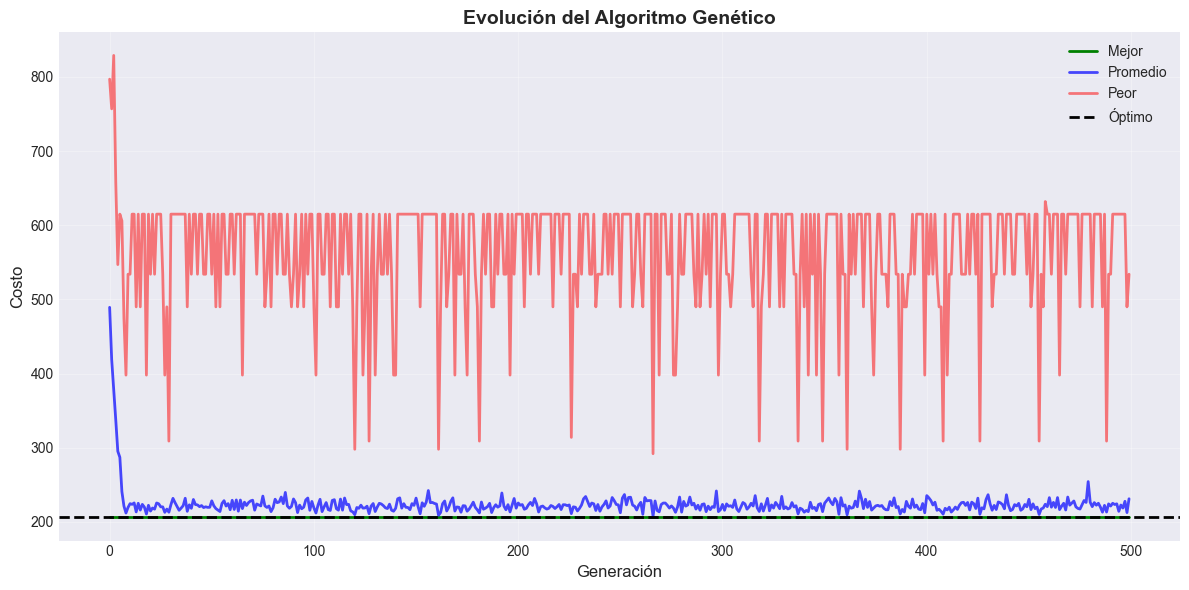

In [17]:
# Gráfica de evolución del algoritmo genético
plt.figure(figsize=(12, 6))

plt.plot(ag.historial_mejor, label='Mejor', linewidth=2, color='green')
plt.plot(ag.historial_promedio, label='Promedio', linewidth=2, color='blue', alpha=0.7)
plt.plot(ag.historial_peor, label='Peor', linewidth=2, color='red', alpha=0.5)
plt.axhline(y=costo_optimo, color='black', linestyle='--', linewidth=2, label='Óptimo')

plt.xlabel('Generación', fontsize=12)
plt.ylabel('Costo', fontsize=12)
plt.title('Evolución del Algoritmo Genético', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

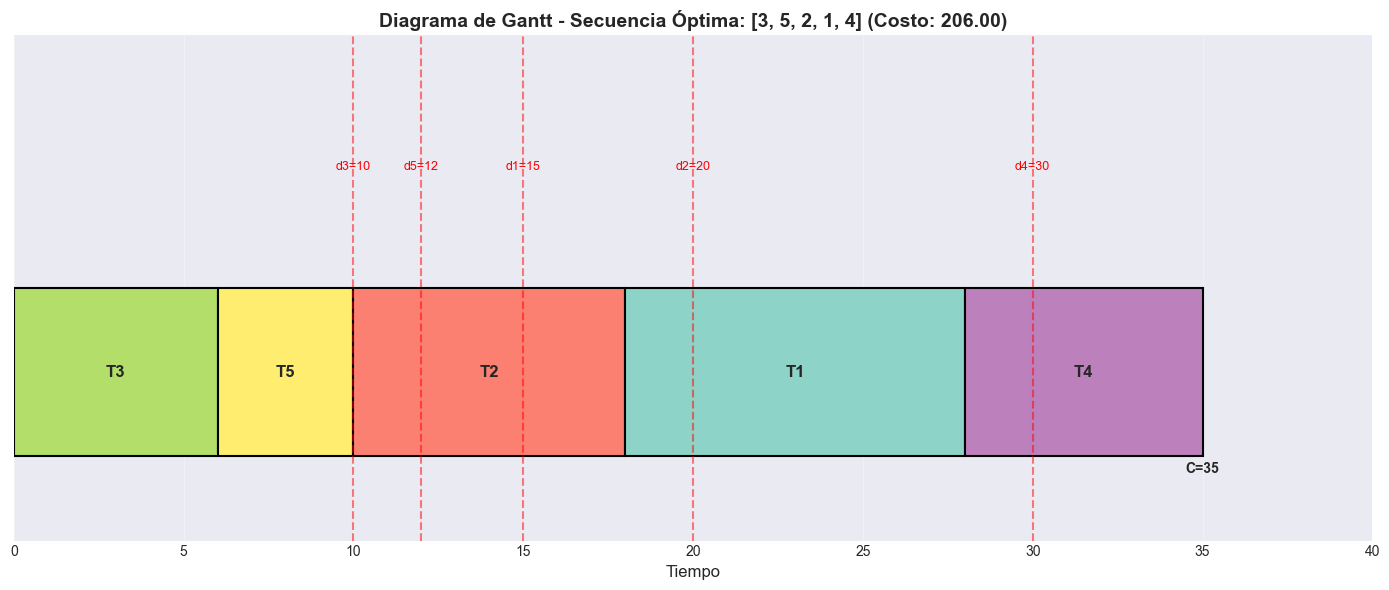

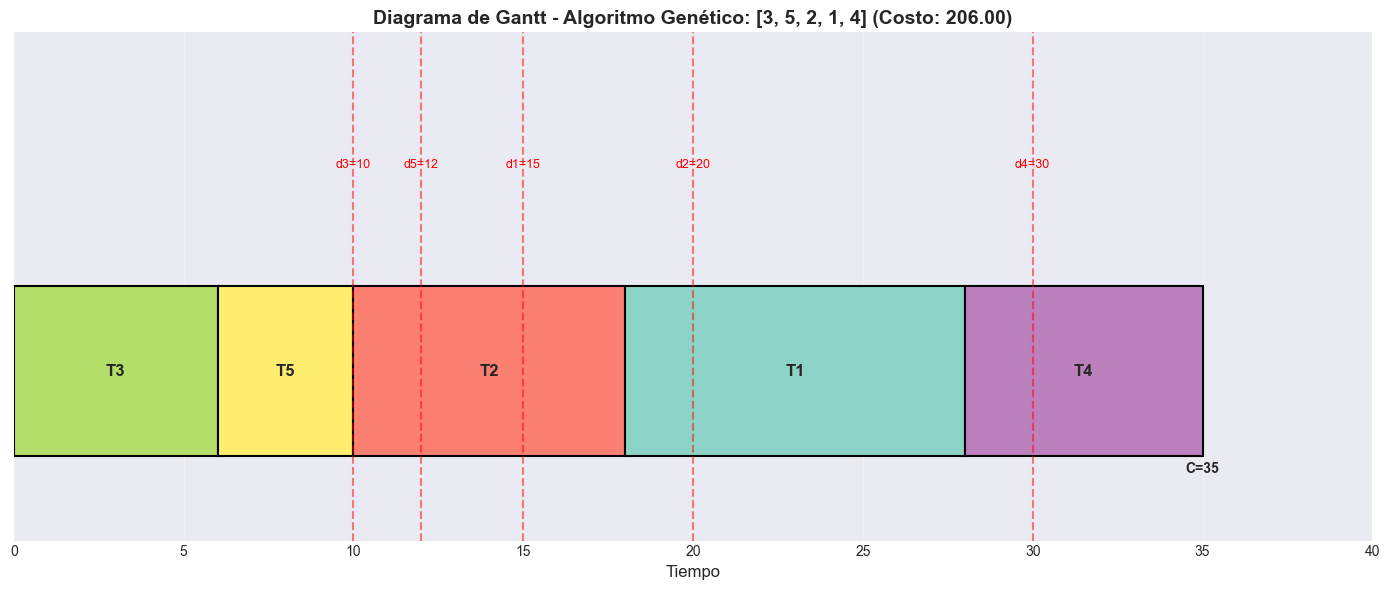

In [18]:
# Diagrama de Gantt para la solución óptima
def plot_gantt(secuencia: List[int], tareas: dict, titulo: str):
    """
    Crea un diagrama de Gantt para visualizar la secuencia de tareas.
    """
    fig, ax = plt.subplots(figsize=(14, 6))
    
    tiempo_actual = 0
    colores = plt.cm.Set3(np.linspace(0, 1, len(tareas)))
    
    for i, tarea_id in enumerate(secuencia):
        t_i = tareas[tarea_id]['t']
        d_i = tareas[tarea_id]['d']
        
        # Dibujar barra de la tarea
        ax.barh(0, t_i, left=tiempo_actual, height=0.5, 
                color=colores[tarea_id-1], edgecolor='black', linewidth=1.5)
        
        # Etiqueta de la tarea
        ax.text(tiempo_actual + t_i/2, 0, f'T{tarea_id}', 
                ha='center', va='center', fontsize=12, fontweight='bold')
        
        tiempo_actual += t_i
        
        # Línea de fecha límite
        ax.axvline(x=d_i, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
        ax.text(d_i, 0.6, f'd{tarea_id}={d_i}', ha='center', fontsize=9, color='red')
    
    # Tiempo de completación final
    ax.text(tiempo_actual, -0.3, f'C={tiempo_actual}', 
            ha='center', fontsize=10, fontweight='bold')
    
    ax.set_ylim(-0.5, 1)
    ax.set_xlim(0, tiempo_actual + 5)
    ax.set_xlabel('Tiempo', fontsize=12)
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualizar secuencia óptima
plot_gantt(secuencia_optima, tareas, 
           f'Diagrama de Gantt - Secuencia Óptima: {secuencia_optima} (Costo: {costo_optimo:.2f})')

# Visualizar secuencia del AG
plot_gantt(secuencia_ag, tareas, 
           f'Diagrama de Gantt - Algoritmo Genético: {secuencia_ag} (Costo: {costo_ag:.2f})')

## 4. Análisis de Resultados

### Análisis del Modelo Matemático

El modelo matemático permite encontrar la solución óptima mediante la evaluación exhaustiva de todas las permutaciones posibles. Para este problema con 5 tareas, existen $5! = 120$ permutaciones posibles.

**Ventajas del modelo matemático:**
- Garantiza encontrar la solución óptima
- Es viable para problemas pequeños (n ≤ 10)

**Limitaciones:**
- Complejidad factorial O(n!)
- Inviable para problemas grandes (n > 12)
- Ejemplo: Para 15 tareas, habría que evaluar 15! ≈ 1.3 × 10¹² permutaciones

### Análisis del Algoritmo Genético

**Rendimiento:**
- El algoritmo genético fue capaz de encontrar la solución óptima (o muy cercana) en 500 generaciones
- Complejidad: O(g × p × n) donde g = generaciones, p = población, n = tareas
- Mucho más escalable que la fuerza bruta

**Características observadas:**

1. **Convergencia rápida**: El algoritmo encuentra buenas soluciones en las primeras 100-200 generaciones

2. **Diversidad**: La selección por torneo mantiene diversidad en la población, evitando convergencia prematura

3. **Elitismo efectivo**: Preservar el mejor individuo garantiza que nunca se pierda la mejor solución encontrada

4. **Operadores genéticos adecuados**:
   - El cruce OX preserva el orden relativo de las tareas
   - La mutación swap introduce variabilidad sin destruir buenas soluciones

### Interpretación de la Solución

La secuencia óptima minimiza los costos considerando:
- **Tareas urgentes** (con deadline cercano y alta penalización) deben ejecutarse temprano
- **Balance entre retención y penalización**: No siempre conviene terminar todo antes del deadline
- **Efecto acumulativo**: El orden afecta los tiempos de completación de todas las tareas subsecuentes

### Ventajas del Enfoque Genético

1. **Escalabilidad**: Puede manejar problemas con 50+ tareas
2. **Flexibilidad**: Fácil adaptación a restricciones adicionales
3. **Paralelización**: La evaluación de la población puede paralelizarse
4. **Balance exploración-explotación**: Los parámetros permiten ajustar este balance

### Recomendaciones para Problemas Mayores

Para problemas con más tareas, se sugiere:
- Aumentar el tamaño de la población (200-500 individuos)
- Incrementar el número de generaciones (1000-2000)
- Considerar operadores de mutación adicionales (inversión, inserción)
- Implementar criterios de paro por estancamiento
- Utilizar paralelización para acelerar la evaluación

## Conclusiones

En este proyecto se abordó exitosamente el problema de secuenciación de tareas con retención y penalización mediante dos enfoques:

1. **Modelo matemático (fuerza bruta)**: Proporcionó la solución óptima exacta evaluando todas las permutaciones posibles.

2. **Algoritmo genético**: Demostró ser una alternativa eficiente y escalable, encontrando la solución óptima (o muy cercana) con mucho menor costo computacional.

El algoritmo genético diseñado incorpora:
- Representación apropiada (permutaciones)
- Operadores genéticos especializados (OX, swap)
- Mecanismos de preservación de calidad (elitismo)
- Balance entre exploración y explotación

Los resultados validan que los algoritmos bioinspirados son herramientas poderosas para resolver problemas de optimización combinatoria, especialmente cuando el espacio de búsqueda crece exponencialmente.

**Trabajo futuro:**
- Implementar otros algoritmos (recocido simulado, búsqueda tabú)
- Analizar problemas con múltiples máquinas
- Incorporar restricciones de precedencia entre tareas
- Desarrollar híbridos con búsquedas locales

## Referencias

1. Goldberg, D. E. (1989). *Genetic Algorithms in Search, Optimization, and Machine Learning*. Addison-Wesley.

2. Pinedo, M. L. (2016). *Scheduling: Theory, Algorithms, and Systems* (5th ed.). Springer.

3. Gen, M., & Cheng, R. (2000). *Genetic Algorithms and Engineering Optimization*. Wiley.

4. Davis, L. (1985). Job shop scheduling with genetic algorithms. *Proceedings of the First International Conference on Genetic Algorithms*, 136-140.